### Get donor level metadata for plotting

We will plot in ggplot() in `R` which has more aesthetic options

In [1]:
import pandas as pd
import scanpy as sc 
import numpy as np

In [2]:
%%time
adata = sc.read_h5ad("../06C_final_adata_for_UCSC.h5ad")
adata

CPU times: user 10.7 s, sys: 57.3 s, total: 1min 7s
Wall time: 1min 7s


AnnData object with n_obs × n_vars = 2275105 × 16115
    obs: 'age', 'donor_id', 'sex', 'disease', 'consistent_cell_type', 'study', 'technology', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'age_group', 'final_cell_type', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'cell_type_plus_subcluster'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'age_disease_colors', 'cell_type_plus_subcluster_colors', 'final_cell_type_colors', 'log1p', 'neighbors', 'study_colors', 'umap', 'v2_scvi_cell_type_colors'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

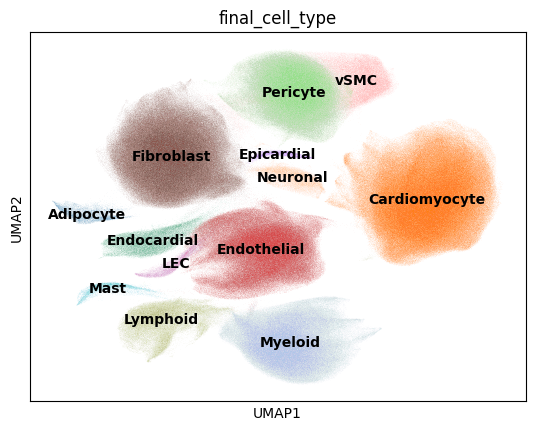

In [9]:
sc.pl.umap(adata, color = "final_cell_type", legend_loc = "on data")

In [4]:
adata.uns['final_cell_type_colors']

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
       '#ff9896'], dtype=object)

In [5]:
# extract the nuclei-level metadata
adata_metadata = adata.obs

In [6]:
adata_metadata.columns

Index(['age', 'donor_id', 'sex', 'disease', 'consistent_cell_type', 'study',
       'technology', 'sample_id', 'age_status', 'tech_plus_study',
       'disease_binary', 'age_group', 'final_cell_type', 'leiden0.25',
       'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5',
       'cell_type_plus_subcluster'],
      dtype='object')

In [7]:
# get donor level metadata
donor_level_metadata = adata_metadata[["age", "donor_id", "sex",
                                       "study", "technology", "age_status", "age_group", "disease",
                                       "tech_plus_study", "disease_binary"]].drop_duplicates().reset_index(drop = True)

In [8]:
donor_level_metadata.to_csv("01_donor_level_metadata.csv")